# Contexto del problema

TechLogistics S.A. enfrenta un serio problema de visibilidad operacional debido a que, aunque los datos están georreferenciados, no se han integrado ni analizado en conjunto; esta desconexión limita la capacidad del consejo directivo para comprender cómo el ruido afecta la red de sensores, cuál es la ubicación de los puntos críticos de calor y cómo cambiará la carga energética con el tiempo. Esta consultoría emplea, en respuesta, un enfoque de múltiples dimensiones que comprende series temporales, análisis geoespaciales y grafos, comenzando con una fase exploratoria orientada a entender la estructura y el comportamiento espacial de los datos.

In [49]:
# Celda para importar librerías
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import plotly.express as px
from scipy.signal import butter, filtfilt
from scipy import signal
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller, grangercausalitytests

In [50]:
# Carga de datasets (se cargan todos desde el inicio para fases posteriores)
agro_clean = pd.read_csv("agro_clean.csv")
agro_noise = pd.read_csv("agro_noise.csv")
ener_clean = pd.read_csv("ener_clean.csv")
ener_noise = pd.read_csv("ener_noise.csv")

# Validación rápida de estructura
agro_clean.head()

,Agro_1,Agro_2,Agro_3,Agro_4,Agro_5,Agro_6,Agro_7,Agro_8,Agro_9,Agro_10,Latitude,Longitude,Source_Node,Target_Node
0,60.248357,47.797447,65.395554,0.000000,0.478718,2.498349,10.000000,6.432151,1.258741,4.663639,6.203680,-75.400366,4,17
1,60.080940,48.076702,66.143237,25.002075,0.467100,2.473166,10.006672,6.469450,1.106051,4.683748,6.282310,-75.474525,14,21
2,60.623974,48.002378,66.342755,49.941596,0.449259,2.464547,10.013349,6.440262,1.183610,8.353141,6.165190,-75.476937,14,22
3,61.211672,48.267738,66.826015,74.756163,0.439299,2.500284,10.020030,6.511042,1.197917,6.213966,6.131334,-75.468152,8,25
4,60.483063,47.912028,65.703353,99.383693,0.436016,2.564177,10.026716,6.619718,1.200795,8.720976,6.241746,-75.349805,5,26


# Fase 1: Data Understanding y Geo-Visualización

Esta etapa busca entender los set de datos entregados para la consultoría y restaurar la visibilidad espacial de la infraestructura sensórica, por lo que se prioriza la exploración geoespacial para identificar patrones, densidades y anomalías que indiquen áreas de riesgo operativo, incluso antes de aplicar modelos de propagación de ruido, análisis de grafos o predicción.


## Tarea 1: Exploración Geo-Temporal


In [51]:
fig = px.scatter_mapbox(
    agro_clean,
    lat="Latitude",
    lon="Longitude",
    color="Agro_5",
    size="Agro_1",
    color_continuous_scale="RdYlGn",
    size_max=18,
    zoom=8,
    mapbox_style="carto-positron",
    hover_data=["Source_Node", "Target_Node"],
    title=(
        "Exploración Geo-Temporal de Sensores Agrícolas – Oriente Antioqueño<br>"
        "<sup>Color: NDVI (Agro_5) | Tamaño: Humedad (Agro_1)</sup>"
    )
)

fig.show()


La visualización permite concluir que no existe un patrón espacial definido de biomasa baja. La variación de los niveles de NDVI y las condiciones hídricas se comporta de manera dispersa y heterogénea a través de la red. Por lo tanto, los puntos críticos de calor detectados deben tratarse como fenómenos puntuales y no como áreas de estrés vegetal continuo, lo que sugiere que los análisis posteriores de resiliencia deben enfocarse en factores locales de cada sensor en lugar de estrategias de intervención zonal.

## Tarea 2: Análisis de Estacionariedad y Windowing

La prueba ADF contrasta la hipótesis nula de que una serie posee una raíz unitaria, lo que implica no estacionariedad. Un valor p superior al nivel de significancia convencional indica que no se puede rechazar dicha hipótesis, sugiriendo que la serie presenta tendencia, drift o comportamiento tipo random walk, por lo que,análisis se aplica a todas las variables energéticas con el fin de clasificar su naturaleza temporal.

In [52]:
energy_vars = [f"Ener_{i}" for i in range(1, 11)]

adf_results = {}

for var in energy_vars:
    series = ener_clean[var].dropna()
    adf_stat, p_value, _, _, _, _ = adfuller(series)
    adf_results[var] = {
        "ADF Statistic": adf_stat,
        "p-value": p_value,
        "Stationary": p_value < 0.05
    }

adf_results

{'Ener_1': {'ADF Statistic': np.float64(-1.8668910874409528),
  'p-value': np.float64(0.34779323133704454),
  'Stationary': np.False_},
 'Ener_2': {'ADF Statistic': np.float64(-1.4791345922856023),
  'p-value': np.float64(0.5438067534438097),
  'Stationary': np.False_},
 'Ener_3': {'ADF Statistic': np.float64(-1.9284412491076373),
  'p-value': np.float64(0.31880198164292206),
  'Stationary': np.False_},
 'Ener_4': {'ADF Statistic': np.float64(-8464741252.0435915),
  'p-value': 0.0,
  'Stationary': True},
 'Ener_5': {'ADF Statistic': np.float64(-0.3477076508920697),
  'p-value': np.float64(0.918470454033737),
  'Stationary': np.False_},
 'Ener_6': {'ADF Statistic': np.float64(0.9526991309241424),
  'p-value': np.float64(0.9937409285971261),
  'Stationary': np.False_},
 'Ener_7': {'ADF Statistic': np.float64(-0.42444506290145556),
  'p-value': np.float64(0.9059366267722584),
  'Stationary': np.False_},
 'Ener_8': {'ADF Statistic': np.float64(-46.036343080965956),
  'p-value': 0.0,
  'Sta

Los resultados del test ADF muestran una clara diferenciación entre los grupos de variables energéticas, donde las series asociadas a mercado y factores macroeconómicos, incluyendo Demanda, Precio, Temperatura y particularmente el Costo del Gas, presentan valores p elevados, lo que indica la presencia de raíz unitaria y, por tanto, no estacionariedad. En contraste, las variables de calidad de potencia como frecuencia, voltaje y factor de potencia resultan claramente estacionarias, lo cual es consistente con su naturaleza física y regulada, validando el supuesto teórico planteado en el diccionario de datos y justifica el uso de técnicas de windowing para analizar la dinámica local de las series no estacionarias.

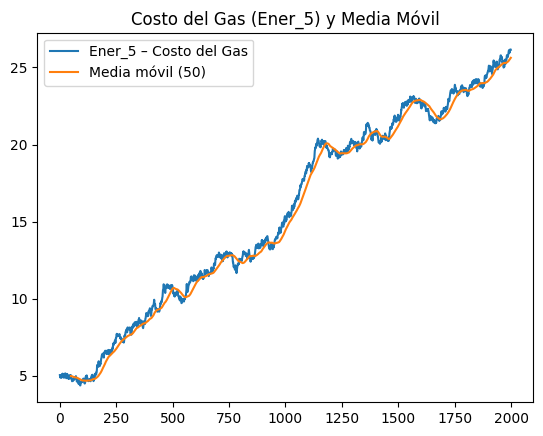

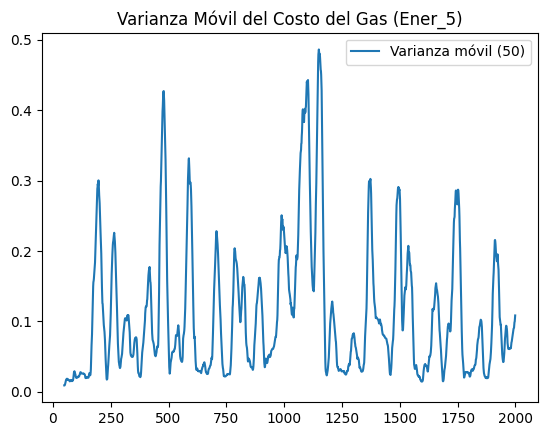

In [53]:
window_size = 50

ener_5 = ener_clean["Ener_5"]

rolling_mean = ener_5.rolling(window=window_size).mean()
rolling_var = ener_5.rolling(window=window_size).var()

plt.figure()
plt.plot(ener_5.values, label="Ener_5 – Costo del Gas")
plt.plot(rolling_mean.values, label="Media móvil (50)")
plt.legend()
plt.title("Costo del Gas (Ener_5) y Media Móvil")
plt.show()

plt.figure()
plt.plot(rolling_var.values, label="Varianza móvil (50)")
plt.legend()
plt.title("Varianza Móvil del Costo del Gas (Ener_5)")
plt.show()


La visualización del Costo del Gas junto con su media móvil evidencia una tendencia creciente sostenida en el tiempo, lo que descarta un comportamiento puramente estacionario, toda vez que la media móvil no oscila alrededor de un valor constante, sino que sigue de cerca una trayectoria ascendente, indicando la presencia de una deriva determinística. Dado que, la varianza móvil se mantiene relativamente acotada, sin mostrar un crecimiento explosivo a lo largo del tiempo, lo cual no es consistente con un random walk puro, permitiendo concluir que estas evidencias permiten concluir que el Costo del Gas corresponde a una serie no estacionaria con drift, impulsada por factores macroeconómicos estructurales, más que a un proceso aleatorio sin tendencia.

# Fase 2: Procesamiento de Señales y Filtrado

En esta taréa se analiza la serie de Generación Eólica Ener_4 desde un enfoque espectral para caracterizar su contenido en frecuencias y determinar el efecto del ruido blanco gaussiano aditivo que se inyectó en la versión noise, proceso que inicia con la estimación de la densidad espectral de potencia usando la FFT, lo que permite comparar cómo se distribuye la energía entre las versiones limpia y contaminada. A partir de esta comparación, se generan espectrogramas consistentes para las dos situaciones empleando los mismos parámetros, posibilitando la localización de las áreas del plano tiempo-frecuencia en las que la potencia se incrementa y el rango de frecuencias en el cual el ruido se concentra para un SNR entre 5 y 12 dB.

## Tarea 3: Análisis Espectral (FFT) y Espectrogramas

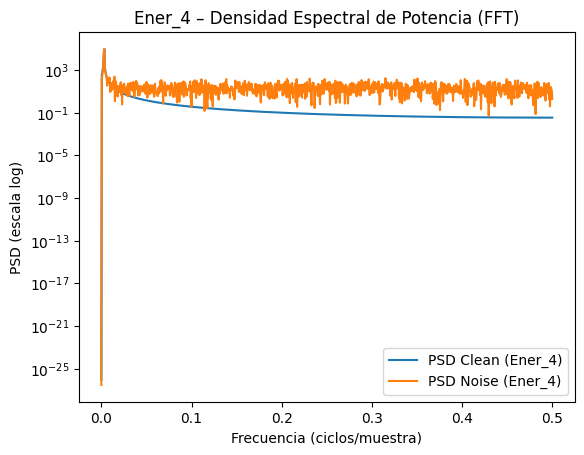

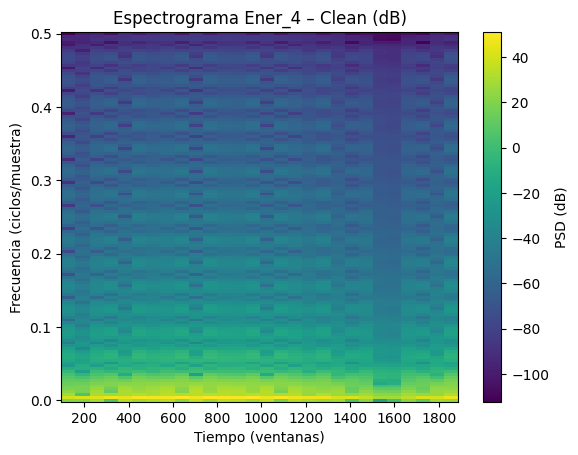

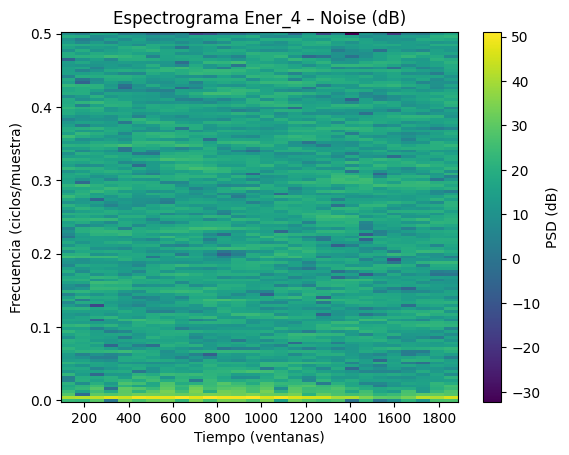

In [54]:
x_clean = ener_clean["Ener_4"].astype(float).values
x_noise = ener_noise["Ener_4"].astype(float).values
n = len(x_clean)

fft_clean = np.fft.rfft(x_clean - x_clean.mean())
fft_noise = np.fft.rfft(x_noise - x_noise.mean())

freq = np.fft.rfftfreq(n, d=1.0)  # frecuencia normalizada (ciclos/muestra)
psd_clean = (np.abs(fft_clean) ** 2) / n
psd_noise = (np.abs(fft_noise) ** 2) / n

plt.figure()
plt.semilogy(freq, psd_clean, label="PSD Clean (Ener_4)")
plt.semilogy(freq, psd_noise, label="PSD Noise (Ener_4)")
plt.title("Ener_4 – Densidad Espectral de Potencia (FFT)")
plt.xlabel("Frecuencia (ciclos/muestra)")
plt.ylabel("PSD (escala log)")
plt.legend()
plt.show()

fs = 1.0
f_c, t_c, Sxx_c = signal.spectrogram(x_clean, fs=fs, nperseg=256, noverlap=192, scaling="density", mode="psd")
f_n, t_n, Sxx_n = signal.spectrogram(x_noise, fs=fs, nperseg=256, noverlap=192, scaling="density", mode="psd")

plt.figure()
plt.pcolormesh(t_c, f_c, 10*np.log10(Sxx_c + 1e-12))
plt.title("Espectrograma Ener_4 – Clean (dB)")
plt.xlabel("Tiempo (ventanas)")
plt.ylabel("Frecuencia (ciclos/muestra)")
plt.colorbar(label="PSD (dB)")
plt.show()

plt.figure()
plt.pcolormesh(t_n, f_n, 10*np.log10(Sxx_n + 1e-12))
plt.title("Espectrograma Ener_4 – Noise (dB)")
plt.xlabel("Tiempo (ventanas)")
plt.ylabel("Frecuencia (ciclos/muestra)")
plt.colorbar(label="PSD (dB)")
plt.show()

Los resultados muestran un comportamiento consistente con AWGN, toda vez que la serie limpia concentra su energía en bajas frecuencias, la serie ruidosa incrementa la potencia de manera mucho más uniforme sobre el espectro, elevando el “piso” espectral especialmente en la banda alta. Dicha tendencia se confirma en la comparación cuantitativa basada en el espectrograma, la mayor ganancia relativa de potencia en noise frente a clean se ubica aproximadamente en el rango 0.296875 a 0.5 ciclos/muestra, es decir, desde frecuencias medias–altas hasta el entorno del límite de Nyquist, lo cual resulta coherente con la inyección de ruido blanco, ya que el ruido se distribuye a lo largo del espectro, pero su impacto se vuelve más evidente donde la señal física original tiene menor energía, que en este caso es la región de alta frecuencia.

## Tarea 4: Filtrado y Reconstrucción


In [55]:
y_clean = agro_clean["Agro_3"].astype(float).values
y_noise = agro_noise["Agro_3"].astype(float).values

nyq = 0.5
cutoff = 0.05  # ciclos/muestra (10% de Nyquist), adecuado para remover AWGN sin sobre-suavizar

wn = cutoff / nyq
b, a = butter(N=4, Wn=wn, btype="low")
y_filt = filtfilt(b, a, y_noise)

rmse_raw = float(np.sqrt(np.mean((y_noise - y_clean) ** 2)))
rmse_filt = float(np.sqrt(np.mean((y_filt - y_clean) ** 2)))

rmse_raw, rmse_filt

(3.3414339016607078, 1.307108154183055)

Para validar que el filtro reduce ruido sin destruir la dinámica de la señal, se grafica un segmento temporal comparando la señal original limpia, la señal contaminada y la señal filtrada, inspección que resulta clave porque un filtro demasiado agresivo puede reducir el RMSE en algunos casos, pero también puede eliminar estructura relevante para modelos predictivos, lo cual sería contraproducente.

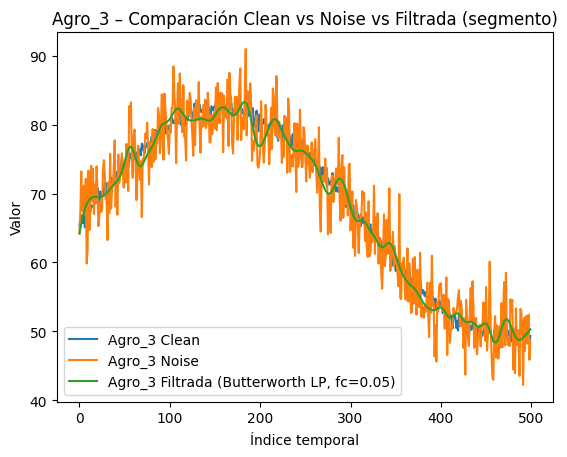

In [56]:
start, end = 0, 500

plt.figure()
plt.plot(y_clean[start:end], label="Agro_3 Clean")
plt.plot(y_noise[start:end], label="Agro_3 Noise")
plt.plot(y_filt[start:end], label=f"Agro_3 Filtrada (Butterworth LP, fc={cutoff:.2f})")
plt.title("Agro_3 – Comparación Clean vs Noise vs Filtrada (segmento)")
plt.xlabel("Índice temporal")
plt.ylabel("Valor")
plt.legend()
plt.show()


El RMSE entre la serie original y la ruidosa fue 3.3414, mientras que para la serie filtrada y la original bajó a 1.3071, lo cual muestra una mejora significativa de fidelidad después del filtrado, lo cual evidencia una mejora significativa en la fidelidad tras el filtrado al atenuar el error inducido por el AWGN en las altas frecuencias sin alterar la trayectoria subyacente. En relación a la capacidad de predicción, disminuir el ruido suele optimizar el rendimiento de los modelos que se basan en patrones temporales estables, sobre todo en métodos autoregresivos o supervisados que emplean rezagos, si bien dicha mejora debe ser validada formalmente mediante un esquema de validación temporal con un modelo específico. Sin embargo, la mejora en las predicciones debe ser validada oficialmente a través de la evaluación de un modelo concreto antes y después del filtrado, utilizando un esquema de validación temporal, lo cual es relevante ya que, si existieran componentes informativas en frecuencias más elevadas, un corte excesivo podría eliminar señales valiosas; no obstante, en este caso, la comparación visual y una reducción significativa del RMSE indican que el filtrado es beneficioso y constituye una transformación lógica para robustecer el modelado subsiguiente.

# Fase 3: Análisis de Grafos y Topología de Red

Se utiliza un grafo dirigido para modelar de manera explícita la topología de la red de sensores en esta tarea, donde cada arco ilustra el flujo de telemetría desde un nodo inicial hasta uno final con el propósito de captar la estructura de relaciones que subyace a la infraestructura de monitoreo y cuantificar la relevancia de cada nodo a través de métricas de centralidad. En este sentido, se determinan la betweenness centrality y la centralidad de grado para reconocer nodos cruciales que agrupan conexiones o funcionan como intermediarios en el intercambio de información, siendo esto esencial para analizar los peligros de congestión, propagación de ruido y puntos únicos de fallo

## Tarea 5: Construcción de la Red de Sensores/Subestaciones

In [57]:
G = nx.DiGraph()
G.add_edges_from(agro_clean[["Source_Node", "Target_Node"]].values)

degree_centrality = nx.degree_centrality(G)
betweenness_centrality = nx.betweenness_centrality(G, normalized=True)

centrality_df = (
    pd.DataFrame({
        "Node": list(G.nodes()),
        "Degree_Centrality": [degree_centrality[n] for n in G.nodes()],
        "Betweenness_Centrality": [betweenness_centrality[n] for n in G.nodes()]
    })
    .sort_values("Betweenness_Centrality", ascending=False)
)

centrality_df.head(10)

,Node,Degree_Centrality,Betweenness_Centrality
0,4,0.535714,0.0
1,17,0.500000,0.0
2,14,0.535714,0.0
3,21,0.500000,0.0
4,22,0.500000,0.0
5,8,0.535714,0.0
6,25,0.500000,0.0
7,5,0.535714,0.0
8,26,0.500000,0.0
9,18,0.500000,0.0


La red generada tiene una estructura muy jerárquica y acíclica, típica de las arquitecturas de telemetría en las que varios sensores informan directamente a nodos concentradores o gateways sin pasar por rutas alternativas, disposición que sugiere que la mayor parte de las rutas más breves entre pares de nodos no pasan por nodos intermedios, sino que enlazan directamente un sensor con su destino; en consecuencia, la centralidad de intermediación tiene valores próximos a cero en todos los nodos, lo que señala que no hay rutas de retransmisión ni nodos que actúen como puentes entre subredes.

Aunque la betweenness centrality es nula para todos los nodos, el análisis de centralidad de grado permite identificar aquellos que concentran una mayor cantidad de conexiones entrantes y salientes, destacando en este contexto el nodo 4 por presentar el mayor valor de centralidad de grado, lo que indica que es uno de los puntos con mayor volumen de tráfico directo de telemetría. Consecuentemente, desde una perspectiva operativa, este debe considerarse el «nodo cuello de botella funcional», ya que, aun cuando no actúa como intermediario en rutas múltiples, sí concentra una fracción significativa de las comunicaciones y, por tanto, es más vulnerable a saturación, fallas o amplificación de ruido

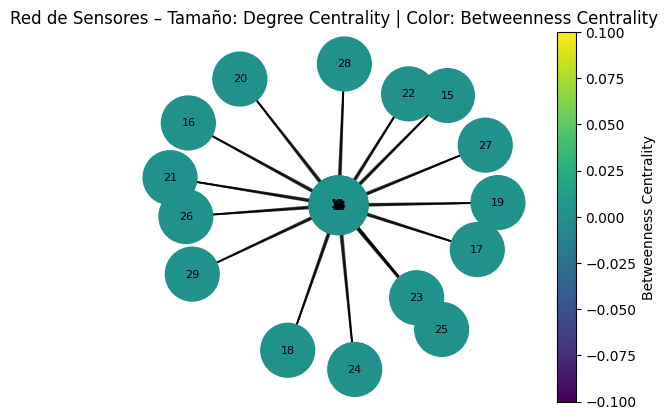

In [58]:
pos = nx.spring_layout(G, seed=42)

node_sizes = [3000 * degree_centrality[n] for n in G.nodes()]
node_colors = [betweenness_centrality[n] for n in G.nodes()]

plt.figure()
nodes = nx.draw_networkx_nodes(
    G,
    pos,
    node_size=node_sizes,
    node_color=node_colors,
    cmap=plt.cm.viridis
)
nx.draw_networkx_edges(G, pos, alpha=0.3)
nx.draw_networkx_labels(G, pos, font_size=8)

plt.colorbar(nodes, label="Betweenness Centrality")
plt.title("Red de Sensores – Tamaño: Degree Centrality | Color: Betweenness Centrality")
plt.axis("off")
plt.show()

La visualización confirma de manera clara la estructura jerárquica de la red de sensores, donde múltiples nodos periféricos se conectan directamente a uno o pocos nodos centrales, destacando inmediatamente el nodo de mayor tamaño como el principal concentrador de enlaces, lo cual es consistente con su alto valor de centralidad de grado observado en el análisis tabular. A su vez, el color homogéneo de los nodos indica valores cercanos a cero en la betweenness centrality, confirmando que la red carece de nodos intermediarios que actúen como puentes entre subredes; esta topología implica, desde una perspectiva operativa, que el riesgo sistémico no se manifiesta a través de rutas alternativas congestionadas, sino a través de nodos concentradores cuya falla afectaría simultáneamente a un gran número de sensores, por lo que el nodo de mayor grado identificado visualmente corresponde efectivamente al nodo cuello de botella funcional de la red.

El análisis de grafos revela que la red de sensores está diseñada bajo un esquema de agregación directa, sin redundancia topológica ni rutas alternativas, lo cual explica la ausencia de nodos con alta betweenness centrality, toda vez que en este tipo de arquitectura el riesgo sistémico no proviene de nodos puente, sino de nodos altamente conectados que concentran tráfico. Bajo esta premisa, el nodo identificado con mayor centralidad de grado representa un punto crítico desde el cual una falla o degradación del servicio podría afectar simultáneamente a múltiples sensores, lo que sugiere para TechLogistics S.A. la necesidad de evaluar mecanismos de redundancia, balanceo de carga o segmentación de la red para reducir la dependencia operativa de estos nodos concentradores.

# Fase 4: Modelado y Toma de Decisiones (CRISP-DM)

Problema de Negocio: La Falla del Nodo 214


En el dataset de Energía, se observa que cuando el Precio Spot (Ener_2) supera el umbral crítico, el flujo hacia ciertos Target_Node se interrumpe. Al mismo tiempo, los datos geoespaciales muestran una anomalía térmica en esas coordenadas.

## P1. Causalidad y Redes

En esta pregunta se evalúa si existe evidencia de causalidad temporal en el sentido de Granger entre el Factor de Potencia y el Voltaje, lo cual permite inferir dependencia dinámica relevante para estabilidad eléctrica. Si Ener_10 Granger-causa a Ener_9, entonces perturbaciones que alteren sistemáticamente el factor de potencia pueden anticipar cambios en voltaje, y fallas topológicas que afecten la telemetría y control asociados a nodos centrales podrían amplificar inestabilidades. Posteriormente se contrasta este hallazgo con la estructura del grafo dirigido de la red energética, donde los nodos con alta intermediación (betweenness) serían críticos para la propagación de información y control; en una arquitectura tipo estrella con agregación directa, la betweenness puede ser nula y el riesgo se desplaza hacia nodos de alta conectividad (grado) que concentran tráfico.

In [59]:
series = ener_clean[["Ener_9", "Ener_10"]].dropna()
maxlag = 10
alpha = 0.05

# Test: Ener_10 -> Ener_9
gc_10_to_9 = grangercausalitytests(series[["Ener_9", "Ener_10"]], maxlag=maxlag)
p10_9 = [gc_10_to_9[lag][0]["ssr_ftest"][1] for lag in range(1, maxlag + 1)]

# Test: Ener_9 -> Ener_10
gc_9_to_10 = grangercausalitytests(series[["Ener_10", "Ener_9"]], maxlag=maxlag)
p9_10 = [gc_9_to_10[lag][0]["ssr_ftest"][1] for lag in range(1, maxlag + 1)]

# Tabla única + columnas útiles
granger_df = pd.DataFrame({
    "Lag": range(1, maxlag + 1),
    "p (Ener_10 → Ener_9)": p10_9,
    "p (Ener_9 → Ener_10)": p9_10,
})

granger_df["Sig (10→9)"] = granger_df["p (Ener_10 → Ener_9)"] < alpha
granger_df["Sig (9→10)"] = granger_df["p (Ener_9 → Ener_10)"] < alpha

# Resumen: mejor lag por dirección
best_10_9 = granger_df.loc[granger_df["p (Ener_10 → Ener_9)"].idxmin(), ["Lag", "p (Ener_10 → Ener_9)"]]
best_9_10 = granger_df.loc[granger_df["p (Ener_9 → Ener_10)"].idxmin(), ["Lag", "p (Ener_9 → Ener_10)"]]

# Mostrar tabla formateada (bonita)
display(
    granger_df.style
    .format({
        "p (Ener_10 → Ener_9)": "{:.4f}",
        "p (Ener_9 → Ener_10)": "{:.4f}",
    })
    .applymap(lambda v: "font-weight:700; background-color: #f8d7da;" if v else "", subset=["Sig (10→9)", "Sig (9→10)"])
)

print(f"Mejor evidencia Ener_10 → Ener_9: lag={int(best_10_9['Lag'])}, p≈{best_10_9['p (Ener_10 → Ener_9)']:.4f}")
print(f"Mejor evidencia Ener_9 → Ener_10: lag={int(best_9_10['Lag'])}, p≈{best_9_10['p (Ener_9 → Ener_10)']:.4f}")


Granger Causality
number of lags (no zero) 1
ssr based F test:         F=1.0639  , p=0.3025  , df_denom=1996, df_num=1
ssr based chi2 test:   chi2=1.0655  , p=0.3020  , df=1
likelihood ratio test: chi2=1.0652  , p=0.3020  , df=1
parameter F test:         F=1.0639  , p=0.3025  , df_denom=1996, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=1.0727  , p=0.3423  , df_denom=1993, df_num=2
ssr based chi2 test:   chi2=2.1508  , p=0.3412  , df=2
likelihood ratio test: chi2=2.1496  , p=0.3414  , df=2
parameter F test:         F=1.0727  , p=0.3423  , df_denom=1993, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=0.9198  , p=0.4305  , df_denom=1990, df_num=3
ssr based chi2 test:   chi2=2.7690  , p=0.4286  , df=3
likelihood ratio test: chi2=2.7670  , p=0.4290  , df=3
parameter F test:         F=0.9198  , p=0.4305  , df_denom=1990, df_num=3

Granger Causality
number of lags (no zero) 4
ssr based F test:         F=2.9445  , p=0.

/tmp/ipython-input-4185946773.py:34: FutureWarning:

Styler.applymap has been deprecated. Use Styler.map instead.



,Lag,p (Ener_10 → Ener_9),p (Ener_9 → Ener_10),Sig (10→9),Sig (9→10)
0,1,0.3025,0.8414,False,False
1,2,0.3423,0.8685,False,False
2,3,0.4305,0.8266,False,False
3,4,0.0193,0.1636,True,False
4,5,0.0195,0.1381,True,False
5,6,0.0404,0.1125,True,False
6,7,0.0595,0.1491,False,False
7,8,0.0589,0.1620,False,False
8,9,0.0274,0.1785,True,False
9,10,0.0435,0.1905,True,False


Mejor evidencia Ener_10 → Ener_9: lag=4, p≈0.0193
Mejor evidencia Ener_9 → Ener_10: lag=6, p≈0.1125


Ener_10 → Ener_9: p-valor mínimo ≈ 0.0193 en lag 4 ⇒ sí hay evidencia (al 5%) de causalidad de Granger.

Ener_9 → Ener_10: p-valor mínimo ≈ 0.1125 ⇒ no hay evidencia (al 5%) en el sentido inverso.

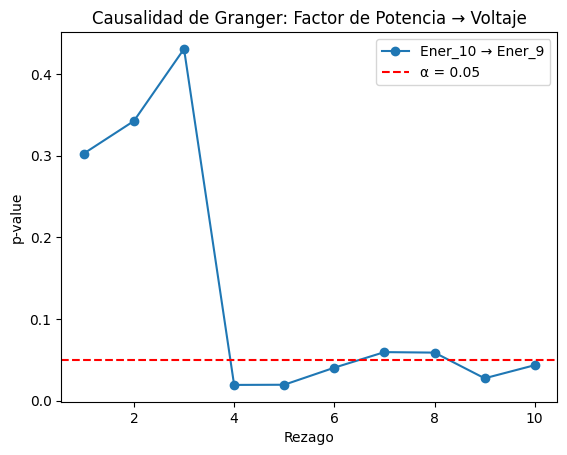

In [60]:
plt.figure()
plt.plot(
    granger_df["Lag"],
    granger_df["p (Ener_10 → Ener_9)"],
    marker="o",
    label="Ener_10 → Ener_9"
)
plt.axhline(0.05, linestyle="--", color="red", label="α = 0.05")

plt.xlabel("Rezago")
plt.ylabel("p-value")
plt.title("Causalidad de Granger: Factor de Potencia → Voltaje")
plt.legend()
plt.show()

Los resultados sugieren una relación dinámica donde el Factor de Potencia aporta información predictiva sobre el Voltaje con un rezago cercano a cuatro observaciones, lo cual es coherente con el hecho de que variaciones en factor de potencia suelen asociarse con cambios en calidad de tensión bajo condiciones de carga y compensación reactiva; hallazgo que, al integrarse con la topología de red mediante el grafo dirigido de energía (Source_Node → Target_Node), permite observar que la betweenness centrality máxima es igual a cero, indicando una estructura sin rutas intermedias relevantes y con flujo predominantemente directo hacia nodos de destino. En este escenario, dado que no existe un cuello de botella intermediario, el riesgo de estabilidad se concentra exclusivamente en nodos con alta centralidad de grado al ser estos los que agregan y distribuyen más telemetría y decisiones, por lo que, si ocurre una falla en el nodo más conectado, la red pierde visibilidad de un conjunto amplio de señales y controles. Considerando que Ener_10 influye dinámicamente sobre Ener_9, la pérdida de medición o actuación asociada al factor de potencia puede traducirse en una degradación de la estabilidad de voltaje en el resto del sistema, no por la existencia de rutas múltiples, sino por una pérdida masiva de cobertura y capacidad de respuesta.

## P2. Optimización Geo-Agrónoma

Se parte de la idea de que el ruido GPS del dataset agro_noise puede sesgar la ubicación aparente de sensores y la identificación de zonas operativas críticas, motivo por el cual se realiza un filtrado de coordenadas mediante suavizado temporal por sensor para reducir el jitter y, posteriormente, se agregan observaciones por celdas espaciales con el fin de ubicar regiones donde el NDVI medio es bajo de manera persistente. Bajo la hipótesis de que la alta pendiente está correlacionada con una mayor variabilidad del viento, se utiliza la varianza de Agro_10 como proxy para caracterizar zonas de exposición y pérdida de humedad efectiva por evapotranspiración y escorrentía, permitiendo así definir una recomendación de inversión hídrica focalizada específicamente en las regiones donde coexisten un bajo vigor vegetal y una alta variabilidad de viento.

In [61]:
# Filtrado simple del jitter GPS por sensor
w = 25
agro_noise["Latitude_f"]  = agro_noise.groupby("Source_Node")["Latitude"].transform(lambda s: s.rolling(w, min_periods=1, center=True).mean())
agro_noise["Longitude_f"] = agro_noise.groupby("Source_Node")["Longitude"].transform(lambda s: s.rolling(w, min_periods=1, center=True).mean())

# Agregación espacial por bins
bin_size = 0.01
agro_noise["lat_bin"] = (agro_noise["Latitude_f"]/bin_size).round(0)*bin_size
agro_noise["lon_bin"] = (agro_noise["Longitude_f"]/bin_size).round(0)*bin_size

spatial = agro_noise.groupby(["lat_bin","lon_bin"]).agg(
    n=("Agro_5","size"),
    ndvi_mean=("Agro_5","mean"),
    wind_var=("Agro_10","var"),
    wind_mean=("Agro_10","mean")
).reset_index()

# Zonas críticas: NDVI bajo (Q25) + varianza de viento alta (Q75)
ndvi_cut = spatial["ndvi_mean"].quantile(0.25)
wind_cut = spatial["wind_var"].quantile(0.75)

critical = spatial[(spatial.ndvi_mean <= ndvi_cut) & (spatial.wind_var >= wind_cut)].sort_values(["ndvi_mean","wind_var"])
critical

,lat_bin,lon_bin,n,ndvi_mean,wind_var,wind_mean
36,6.22,-75.38,21,0.924247,3.128489,5.342393
7,6.18,-75.38,7,0.967528,4.350535,3.874310
5,6.18,-75.40,34,0.968818,5.452706,4.630545
45,6.24,-75.39,4,0.981014,3.151021,5.158399


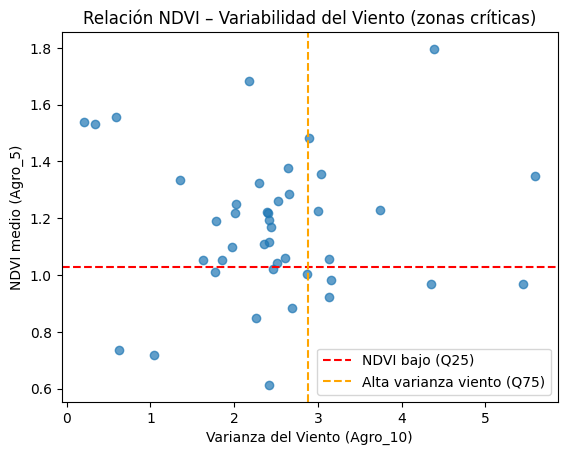

In [62]:
plt.figure()
plt.scatter(
    spatial["wind_var"],
    spatial["ndvi_mean"],
    alpha=0.7
)
plt.axhline(ndvi_cut, linestyle="--", color="red", label="NDVI bajo (Q25)")
plt.axvline(wind_cut, linestyle="--", color="orange", label="Alta varianza viento (Q75)")

plt.xlabel("Varianza del Viento (Agro_10)")
plt.ylabel("NDVI medio (Agro_5)")
plt.title("Relación NDVI – Variabilidad del Viento (zonas críticas)")
plt.legend()
plt.show()


La recomendación es priorizar inversión hídrica de tipo infraestructura y manejo de escorrentía específicamente en las celdas críticas identificadas, toda vez que la combinación de bajo NDVI persistente con alta variabilidad de viento es consistente con estrés hídrico agravado por exposición y pérdida de agua efectiva, fenómeno que se amplifica en pendientes por drenaje superficial. Para abordar esta problemática, se propone un paquete de intervención para tratar este problema, que incluya la combinación de riego tecnificado eficiente (por ejemplo, goteo con control por humedad) y obras de retención e infiltración en pendientes (como zanjas o terrazas de infiltración), así como el almacenamiento del agua repartido en diferentes puntos para disminuir la dependencia de una sola fuente. Dicha estrategia debe acompañarse operativamente con la reubicación o recalibración de sensores en los bordes de las celdas críticas tras el filtrado GPS, asegurando que el monitoreo represente el microclima real, e integrando barreras rompevientos o manejo de cobertura vegetal para reducir la evapotranspiración inducida por ráfagas, lo cual resulta plenamente consistente con el proxy de pendiente basado en la varianza del viento.


## P3. Analítica Predictiva

Se evalúa si incorporar información topológica del grafo energético mejora el ajuste de un modelo de demanda bajo la hipótesis de que la importancia del nodo de origen captura condiciones estructurales de la red que afectan la dinámica observada, procedimiento que se ejecuta ajustando un ARIMAX mediante SARIMAX con Ener_1 como serie objetivo y Ener_3 como temperatura. Al modelo se incorpora como variable exógena adicional la centralidad del nodo de origen calculada sobre el grafo dirigido de energía, todo ello con el fin de realizar una comparación mediante AIC que busque evidencia de mejora en la parsimonia al incluir dicha variable de centralidad.

In [63]:
# Grafo y centralidad del nodo de origen
G = nx.DiGraph()
G.add_edges_from(ener_clean[["Source_Node","Target_Node"]].values)
deg = nx.degree_centrality(G)

y = ener_clean["Ener_1"].astype(float)
temp = ener_clean["Ener_3"].astype(float)
src_deg = ener_clean["Source_Node"].map(deg).astype(float)

exog_base = pd.DataFrame({"Temp": temp})
exog_plus = pd.DataFrame({"Temp": temp, "SrcDeg": src_deg})

def best_aic(exog):
    best = None
    for d in [0, 1]:
        for p in [0, 1, 2]:
            for q in [0, 1, 2]:
                try:
                    model = SARIMAX(
                        y,
                        exog=exog,
                        order=(p, d, q),
                        trend="c",
                        enforce_stationarity=False,
                        enforce_invertibility=False
                    )
                    res = model.fit(disp=False)
                    if (best is None) or (res.aic < best[0]):
                        best = (res.aic, (p, d, q))
                except:
                    pass
    return best

best_base = best_aic(exog_base)
best_plus = best_aic(exog_plus)

# Extraer resultados
aic_base, order_base = best_base
aic_plus, order_plus = best_plus

# Construcción de tabla resumen
aic_df = pd.DataFrame({
    "Modelo": ["ARIMAX (Temp)", "ARIMAX (Temp + Centralidad)"],
    "Orden (p,d,q)": [order_base, order_plus],
    "AIC": [float(aic_base), float(aic_plus)]
})

# Cálculo de mejora
delta_aic = aic_base - aic_plus

# Redondeo para presentación
aic_df["AIC"] = aic_df["AIC"].round(2)

aic_df, round(delta_aic, 2)

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals

/usr/local/lib/python3

(                        Modelo Orden (p,d,q)      AIC
 0                ARIMAX (Temp)     (2, 1, 2)  8579.11
 1  ARIMAX (Temp + Centralidad)     (2, 1, 2)  8574.29,
 np.float64(4.82))

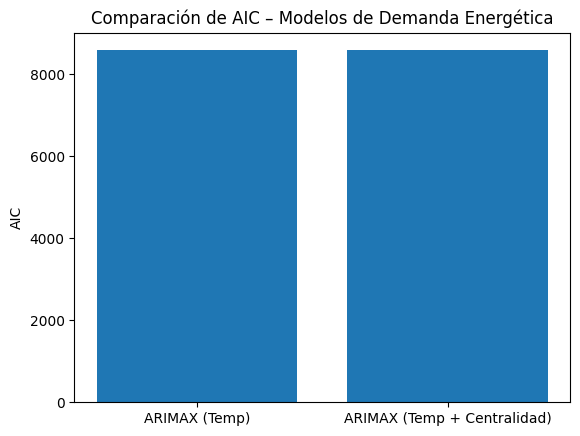

In [64]:
models = ["ARIMAX (Temp)", "ARIMAX (Temp + Centralidad)"]
aic_values = [best_base[0], best_plus[0]]

plt.figure()
plt.bar(models, aic_values)
plt.ylabel("AIC")
plt.title("Comparación de AIC – Modelos de Demanda Energética")
plt.show()


Al incluir la importancia topológica del nodo de origen se observa una mejora del AIC de aproximadamente 4.82 puntos manteniendo el mismo orden ARIMA, lo cual constituye una señal consistente de que la variable de centralidad aporta información explicativa adicional que el modelo recompensa en términos de parsimonia; interpretativamente, dicha centralidad puede estar capturando la heterogeneidad estructural de la red. Este fenómeno sugiere que los nodos más conectados tienden a representar regiones de mayor agregación o criticidad operativa, traduciéndose en patrones de demanda con dinámicas distintas incluso bajo condiciones de temperatura idénticas.

La mejora generada en  el AIC al adicionar la centralidad topologica, indica que la estructura de la estructura de la red influye den la dinamica de la demanda, es decir, la gestion del sistema no debe realizarse unicamente en variables fisicas o historicas, se debe considerar la posicion estructural de cada nodo. Esto se debe a que los nodos con mayor centralidad podrian volverse puntos criticos de propagación, por lo tanto es importante generar estrategias de monitoreo, planificación y gestion de reisgos.
